In [4]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt

from ultrasound_tracker.geometry import (
    line_angle,
    line_angle_from_array,
    line_angles_batch,
    normalize_angle,
    line_length,
    line_length_from_array,
    line_lengths_batch,
    pennation_angle,
    pennation_angle_from_lines,
    point_to_line_distance,
    project_point_on_line,
    line_intersection,
    translate_line,
    translate_lines_batch,
    FascicleGeometry,
    compute_line_features,
    filter_lines_by_angle,
    filter_lines_by_length,
    is_valid_line,
    clip_line_to_image,
)

print("geometry.py importé avec succès")


geometry.py importé avec succès


In [6]:
print("Angle horizontal :", line_angle(0, 0, 10, 0))
print("Angle up-right :", line_angle(0, 0, 10, -10))
print("Angle down-right :", line_angle(0, 0, 10, 10))

print("Longueur 3-4-5 :", line_length(0, 0, 3, 4))

assert np.isclose(line_angle(0, 0, 10, 0), 0)
assert np.isclose(line_angle(0, 0, 10, -10), 45)
assert np.isclose(line_angle(0, 0, 10, 10), -45)
assert np.isclose(line_length(0, 0, 3, 4), 5)

print("Tests de base OK")

Angle horizontal : 0.0
Angle up-right : 45.0
Angle down-right : -45.0
Longueur 3-4-5 : 5.0
Tests de base OK


In [7]:
sup_apo = np.array([20, 100, 500, 120], dtype=np.float32)
deep_apo = np.array([20, 350, 500, 370], dtype=np.float32)
fascicle = np.array([180, 110, 300, 360], dtype=np.float32)

geom = FascicleGeometry(
    fascicle=fascicle,
    superficial_apo=sup_apo,
    deep_apo=deep_apo
)

print(geom)
print("Angle fascicule :", geom.fascicle_angle)
print("Angle apo superficielle :", geom.superficial_apo_angle)
print("Angle apo profonde :", geom.deep_apo_angle)
print("Pennation :", geom.pennation_angle_val)
print("Endpoints fascicule :", geom.get_fascicle_endpoints())
print("Attachment superficiel :", geom.get_superficial_attachment())
print("Attachment profond :", geom.get_deep_attachment())

FascicleGeometry(angle=-64.36°, length=277.3px, pennation=-61.97°)
Angle fascicule : -64.35899
Angle apo superficielle : -2.385944
Angle apo profonde : -2.385944
Pennation : -61.973053
Endpoints fascicule : ((180.0, 110.0), (300.0, 360.0))
Attachment superficiel : (180.13865661621094, 106.67244720458984)
Attachment profond : (299.9306640625, 361.6637878417969)


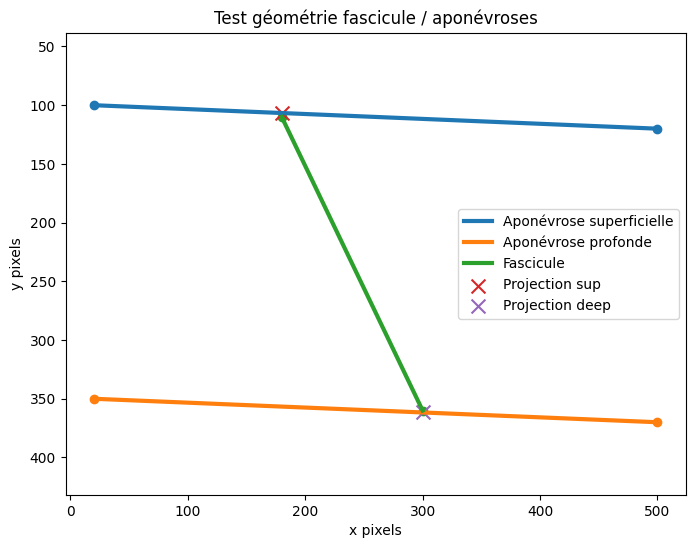

In [8]:
def plot_line(line, label=None, linewidth=3):
    x1, y1, x2, y2 = line
    plt.plot([x1, x2], [y1, y2], linewidth=linewidth, label=label)
    plt.scatter([x1, x2], [y1, y2])

plt.figure(figsize=(8, 6))

plot_line(sup_apo, "Aponévrose superficielle")
plot_line(deep_apo, "Aponévrose profonde")
plot_line(fascicle, "Fascicule")

sup_attach = geom.get_superficial_attachment()
deep_attach = geom.get_deep_attachment()

if sup_attach is not None:
    plt.scatter(*sup_attach, s=100, marker="x", label="Projection sup")
if deep_attach is not None:
    plt.scatter(*deep_attach, s=100, marker="x", label="Projection deep")

plt.gca().invert_yaxis()
plt.axis("equal")
plt.legend()
plt.title("Test géométrie fascicule / aponévroses")
plt.xlabel("x pixels")
plt.ylabel("y pixels")
plt.show()

Intersection fascicule / apo sup : (178.36734008789062, 106.59864044189453)
Intersection fascicule / apo deep : (300.8163146972656, 361.70068359375)


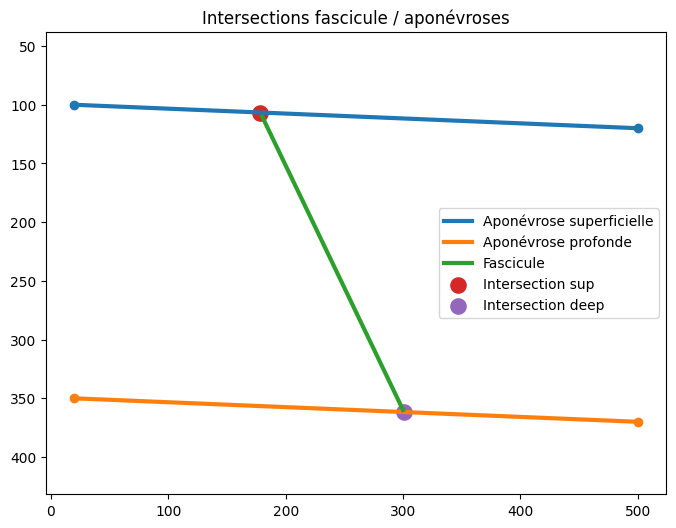

In [9]:
intersection_sup = line_intersection(*fascicle, *sup_apo)
intersection_deep = line_intersection(*fascicle, *deep_apo)

print("Intersection fascicule / apo sup :", intersection_sup)
print("Intersection fascicule / apo deep :", intersection_deep)

plt.figure(figsize=(8, 6))

plot_line(sup_apo, "Aponévrose superficielle")
plot_line(deep_apo, "Aponévrose profonde")
plot_line(fascicle, "Fascicule")

if intersection_sup is not None:
    plt.scatter(*intersection_sup, s=120, marker="o", label="Intersection sup")
if intersection_deep is not None:
    plt.scatter(*intersection_deep, s=120, marker="o", label="Intersection deep")

plt.gca().invert_yaxis()
plt.axis("equal")
plt.legend()
plt.title("Intersections fascicule / aponévroses")
plt.show()

In [10]:
lines = np.array([
    [0, 0, 100, 0],
    [0, 0, 100, -100],
    [0, 0, 100, 100],
    [0, 0, 30, 40],
], dtype=np.float32)

features = compute_line_features(lines)

print("Angles :", features["angles"])
print("Lengths :", features["lengths"])
print("Midpoints :")
print(features["midpoints"])

Angles : [ -0.      45.     -45.     -53.1301]
Lengths : [100.      141.42136 141.42136  50.     ]
Midpoints :
[[ 50.   0.]
 [ 50. -50.]
 [ 50.  50.]
 [ 15.  20.]]


In [11]:
angles = features["angles"]
lengths = features["lengths"]

filtered_lines_angle, filtered_angles = filter_lines_by_angle(
    lines,
    angles,
    angle_min=20,
    angle_max=60
)

print("Lignes gardées par angle :")
print(filtered_lines_angle)
print("Angles gardés :", filtered_angles)

filtered_lines_length, filtered_lengths = filter_lines_by_length(
    lines,
    lengths,
    length_min=80
)

print("Lignes gardées par longueur :")
print(filtered_lines_length)
print("Longueurs gardées :", filtered_lengths)

Lignes gardées par angle :
[[   0.    0.  100. -100.]]
Angles gardés : [45.]
Lignes gardées par longueur :
[[   0.    0.  100.    0.]
 [   0.    0.  100. -100.]
 [   0.    0.  100.  100.]]
Longueurs gardées : [100.      141.42136 141.42136]


In [12]:
line = np.array([10, 20, 100, 200], dtype=np.float32)

translated = translate_line(line, dx=5, dy=-10)
clipped = clip_line_to_image(np.array([-10, 20, 600, 800], dtype=np.float32), img_width=562, img_height=706)

print("Original :", line)
print("Translated :", translated)
print("Clipped :", clipped)
print("Valid original :", is_valid_line(line))

Original : [ 10.  20. 100. 200.]
Translated : [ 15.  10. 105. 190.]
Clipped : [  0.  20. 561. 705.]
Valid original : True


In [13]:
def test_geometry_module():
    assert np.isclose(line_angle(0, 0, 1, 0), 0)
    assert np.isclose(line_angle(0, 0, 1, -1), 45)
    assert np.isclose(line_angle(0, 0, 1, 1), -45)
    assert np.isclose(line_length(0, 0, 3, 4), 5)

    d = point_to_line_distance(1, 1, 0, 0, 2, 0)
    assert np.isclose(d, 1.0)

    p = project_point_on_line(1, 1, 0, 0, 2, 0)
    assert np.allclose(p, (1, 0))

    inter = line_intersection(0, 0, 10, 10, 0, 10, 10, 0)
    assert np.allclose(inter, (5, 5))

    fascicle = np.array([180, 110, 300, 360], dtype=np.float32)
    deep_apo = np.array([20, 350, 500, 370], dtype=np.float32)

    geom = FascicleGeometry(fascicle=fascicle, deep_apo=deep_apo)
    assert geom.fascicle_length > 0
    assert geom.pennation_angle_val is not None

    print("Tous les tests geometry.py passent")

test_geometry_module()

Tous les tests geometry.py passent
